<a href="https://colab.research.google.com/github/adc-trust-ai/adc-trust-ai/blob/main/notebooks/trust_free_tutorial_Kaggle_insurance_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable Regression on the Medical Insurance Dataset 🏥, Powered by trust-free

This notebook demonstrates **trust-free**, the Python implementation of the PRICAI 2025 [TRUST algorithm](https://arxiv.org/abs/2506.15791), on the widely used Kaggle [Medical Insurance dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance/data) (1.9M views, 383K downloads) from Brett Lantz’s book *Machine Learning with R*.

We show how a **2-leaf TRUST™ tree**, with sparse linear models in each leaf, can match — and in some metrics even slightly exceed — the predictive power of *fully tuned* Random Forest and XGBoost models, **while remaining completely interpretable**.  

A model this simple shouldn’t be this good — and yet, it is.

## Installation ⚙️

This notebook requires **trust-free** (**Python 3.11-3.12**). You can install it by simply running the cell below.

In [1]:
%pip install trust-free

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.9 MB/s eta 0:00:00
  Created wheel for libsvmdata: filename=libsvmdata-0.5-py3-none-any.whl size=9286 sha256=87485581d8290e70807fb49af28c8a478ce3ebbaf1b750274e7c4dd6eaede1e8
  Stored in directory: /root/.cache/pip/wheels/a1/fb/5c/cf849e5f9a39cd3fb92a0ad2cd5256d6628a1adca98e49941a
Successfully built libsvmdata
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
 

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

# TRUST-free
from trust import TRUSTRegressor

# Competing models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

## Load Dataset and Exploratory Data Analysis 📊

1338 6
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


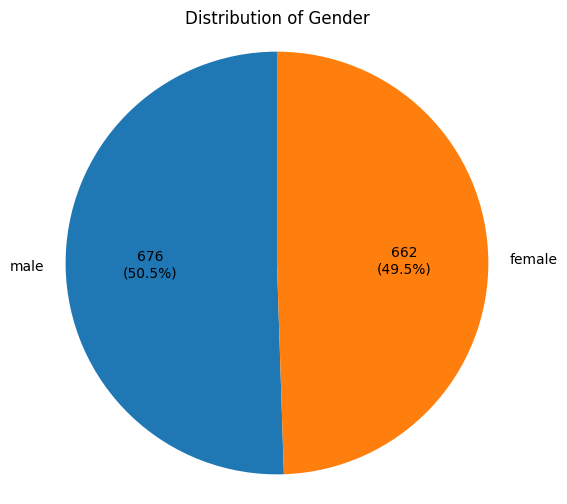

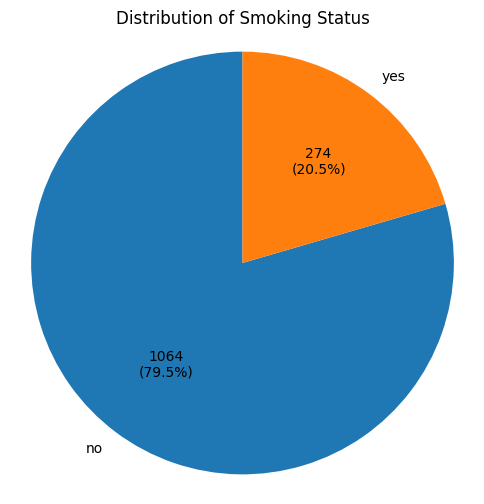

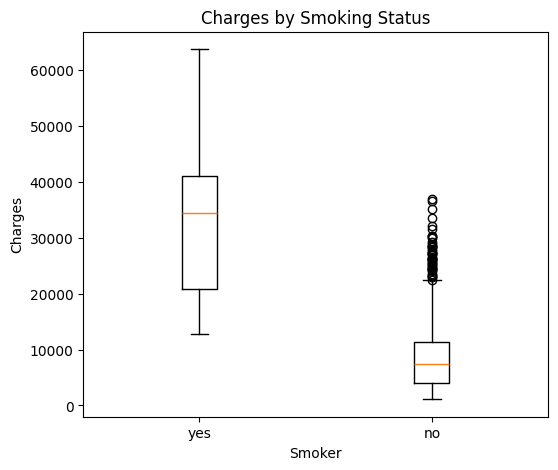

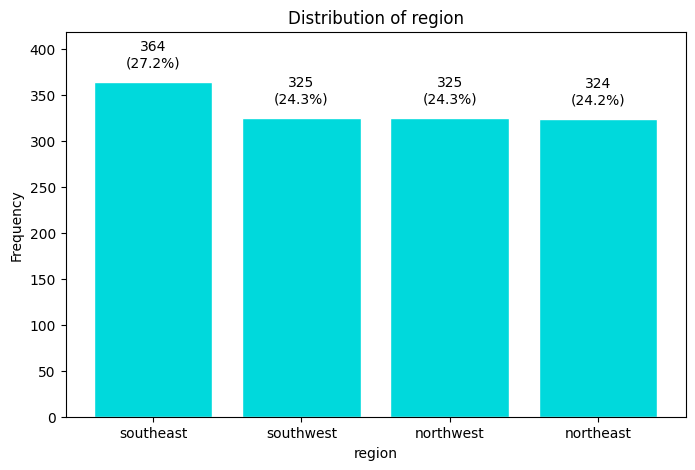

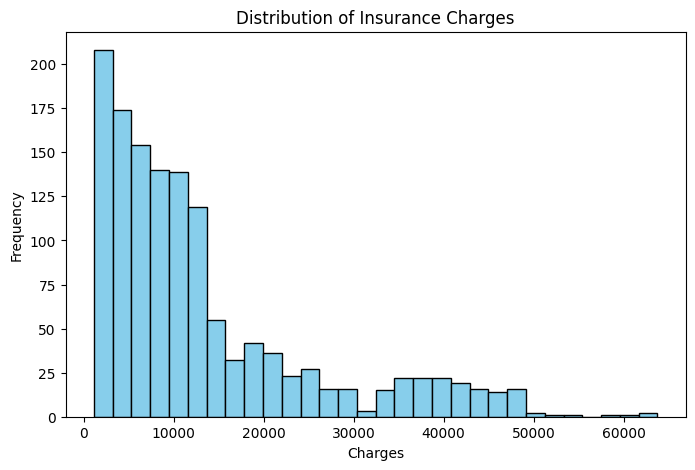

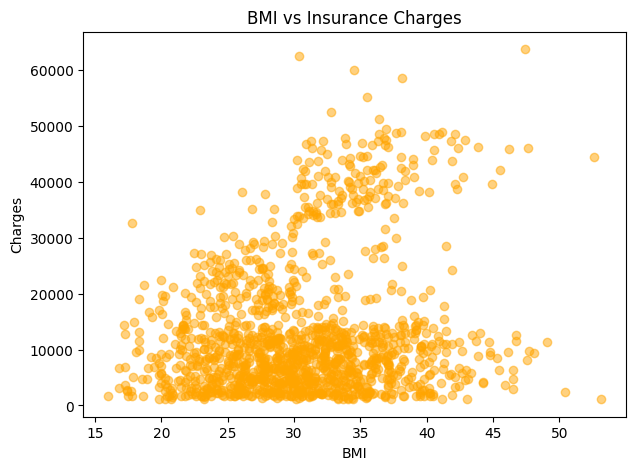

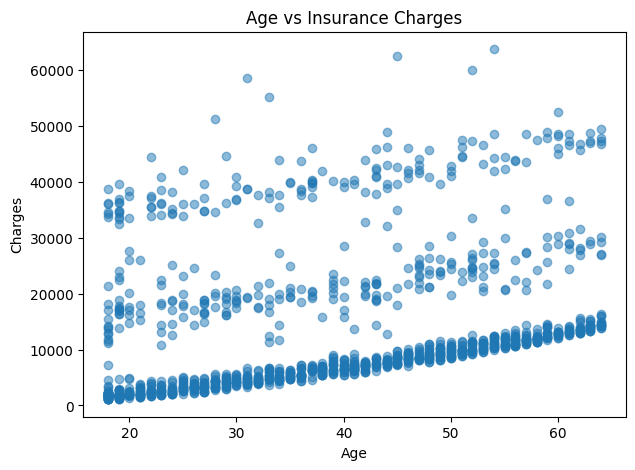

In [4]:
Insurance = pd.read_csv("https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/data/insurance.csv")
Insurance_X = Insurance.iloc[:,:-1]
Insurance_y = Insurance.iloc[:,-1]
n,p = np.shape(Insurance_X)
print(n,p)
print(Insurance.head())
Insurance.isnull().values.any() #check if there are any NaNs
# Quick summary for numeric variables
Insurance.describe()
# Complementary plotting for discrete ones
gender_counts = Insurance['sex'].value_counts()
total = gender_counts.sum()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct=lambda pct: f"{int(round(pct*total/100))}\n({pct:.1f}%)",
    startangle=90
)
plt.title("Distribution of Gender")
plt.axis("equal")
plt.show()

smoking_counts = Insurance['smoker'].value_counts()
total = smoking_counts.sum()

plt.figure(figsize=(6,6))
plt.pie(
    smoking_counts,
    labels=smoking_counts.index,
    autopct=lambda pct: f"{int(round(pct*total/100))}\n({pct:.1f}%)",
    startangle=90
)
plt.title("Distribution of Smoking Status")
plt.axis("equal")
plt.show()

plt.figure(figsize=(6,5))
categories = Insurance['smoker'].unique()
data_to_plot = [Insurance[Insurance['smoker']==cat]['charges'] for cat in categories]

plt.boxplot(data_to_plot, tick_labels=categories)
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

def plot_categorical_bar(df, column, figsize=(8,5), color='#00d9dc', edgecolor='white'):
    """
    Plots a bar chart for a categorical column with counts and percentages on top.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the column.
    column : str
        The name of the categorical column to plot.
    figsize : tuple
        Size of the figure.
    color : str
        Color of the bars (default: teal)
    edgecolor : str
        Edge color of the bars.
    """
    counts = df[column].value_counts()
    total = counts.sum()

    plt.figure(figsize=figsize)
    bars = plt.bar(counts.index, counts.values, color=color, edgecolor=edgecolor)

    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        plt.text(
            bar.get_x() + bar.get_width()/2,
            count + total*0.01,
            f"{count}\n({pct:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.ylim(0, max(counts.values)*1.15)
    plt.show()

plot_categorical_bar(Insurance, 'region')

# Some more plotting
plt.figure(figsize=(8,5))
plt.hist(Insurance['charges'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(Insurance['bmi'], Insurance['charges'], alpha=0.5, color="orange")
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(Insurance['age'], Insurance['charges'], alpha=0.5)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

Key observations:
- Charges tend to be higher for smokers.
- Charges seem to correlate positively with both BMI and age, but the raw signal is noisy.
- Extreme BMI values ($>$45) exist but could be realistic, not necessarily errors.

## Data Preprocessing 🔧

The dataset is already in good shape, with no missing values to handle.  

We still need a few preprocessing steps, such as creating a train–test split and applying one-hot encoding to categorical variables. These steps are required for standard models like Random Forest, XGBoost, and Lasso — but not for **TRUST™**, which can natively handle categorical features and missing values without extra preprocessing.  

In [5]:
# Make train (70%) - test (30%) split (note: I always use the same seed in all my works)
X_train, X_test, y_train, y_test = train_test_split(Insurance_X, Insurance_y, test_size=0.3, random_state=123)

X_1Hot_enc = pd.get_dummies(Insurance_X, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
X_train_1Hot_enc, X_test_1Hot_enc, y_train, y_test = train_test_split(X_1Hot_enc, Insurance_y, test_size=0.3, random_state=123)
scaler = StandardScaler() #only strictly needed for Lasso, but doesn't hurt to do it for all models
X_train_1Hot_enc_scaled = scaler.fit_transform(X_train_1Hot_enc)
X_test_1Hot_enc_scaled = scaler.transform(X_test_1Hot_enc)

## Fit a TRUST™ Model 🤖

Fitting a TRUST model is straightforward.  

For maximum interpretability, we set the maximum tree depth to 1 (giving a simple 2-leaf tree) and provide the indices of the categorical variables in the dataset.  

Everything else is handled automatically by **trust-free**.

As we will see, this extremely simple architecture will be enough!

In [7]:
# Instantiate and fit your model
model = TRUSTRegressor().fit(X_train, y_train, catvar=[1,4,5])

# Predict and print results
y_pred_trust = model.predict(X_test)
print("\nPredictions:", np.round(y_pred_trust[:5]))
print("True y values:", np.round(y_test.values[:5]))
r2_trust = r2_score(y_test, y_pred_trust)
rmse_trust = root_mean_squared_error(y_test, y_pred_trust)
print(f"TRUST R²: {r2_trust:.4f}, RMSE: ${rmse_trust:.2f}")

    TRUST™: Transparent, Robust & Ultra-Sparse Trees [v3.0.0]    
Copyright © 2024-2026 Albert Dorador Chalar. All rights reserved.
⚙️ Training model...
  - Number of samples: 936
  - Number of features: 6
  - Categorical features:
    - sex
    - smoker
    - region
  - Number of missing values: 0
  ℹ️ High imbalance: over 75% of values in categorical variable 'smoker' (index 4) belong to a single category.
  ℹ️ Switching to standard scaling to avoid incorrect scaling caused by zero IQR fallback in robust scaler.

  > Progressive CV started. Less promising depths will be progressively discarded.
   - Number of folds: 5
   - Depths to test: [0, 1, 2, 3, 4]
   - Total models to fit: 19 (instead of 25 with standard CV)
    Progress: [████████████████████████████████████████] 100%
 > Progressive CV completed. Time elapsed: 6.88 seconds.

Max depth chosen by progressive cross-validation: 1.
Proceeding to train a Renet™ Tree with CV-optimized max depth of 1.
Expected time to completion: ~0 

## Visualize the TRUST™ Tree 🌲

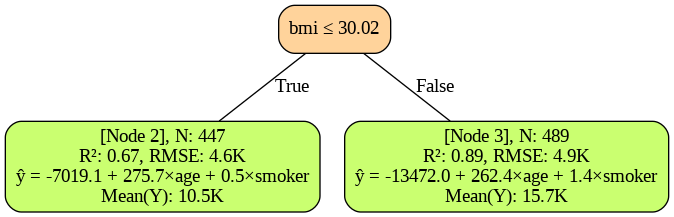

In [8]:
model.plot_tree("Insurance")

The trust-free model splits at **BMI $\leq$ 30**, which *coincides* with the clinical obesity threshold defined by the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight).

<table>
<tr>
  <td>
    <table border="1">
      <caption>Left Leaf</caption>
      <tr><th>Feature</th><th>Estimate</th><th>P-value</th></tr>
      <tr><td>Intercept</td><td>-7019.13</td><td>1.746380e-21</td></tr>
      <tr><td>age</td><td>275.73</td><td>1.462447e-51</td></tr>
      <tr><td>smoker</td><td>0.55</td><td>3.784630e-81</td></tr>  
    </table>
  </td>
  <td>
    <table border="1">
      <caption>Right Leaf</caption>
      <tr><th>Feature</th><th>Estimate</th><th>P-value</th></tr>
      <tr><td>Intercept</td><td>-13472.01</td><td>3.486333e-58</td></tr>
      <tr><td>age</td><td>262.40</td><td>4.746685e-52</td></tr>
      <tr><td>smoker</td><td>1.39</td><td>1.121560e-228</td></tr>
    </table>
  </td>
</tr>
</table>

Note: The coefficient for smoker must be interpreted relative to its encoding, which is based on the average charges of each category in the training data (using cross-validation and smoothing to avoid signal leaking and overfitting):

| smoker | smoker_encoded |
|--------|----------------|
| no     | 8497.513965    |
| yes    | 32333.840649   |


Key insights:
1. In all cases, **charges tend to increase** for **older** patients 👵🏻👴🏻: each additional year is associated with $\$255-\$271$ more
2. For clinically *obese* individuals (BMI > 30), **smoking** matters nearly *3 times more* 🚬🚬🚬: smokers pay on average over $\$33,000$ more compared to non-smokers, vs. $\$13,000$ in the non-obese group

Takeaway 👉: **trust-free** not only rediscovers well-known medical risk factors on its own, but also pinpoints their interaction: obesity amplifies the financial penalty of smoking.

With his sparse structure we can obtain **full interpretability**... while matching ensemble performance (!), as we will see later.

## Feature Importance 📈

Next we will discover how important each variable is for the specific model that we have just fitted. To accomplish this, "One Permutation Is All You Need" (https://arxiv.org/abs/2512.13892).


📊 TRUST™ Direct Variable Importance ('One Permutation Is All You Need')


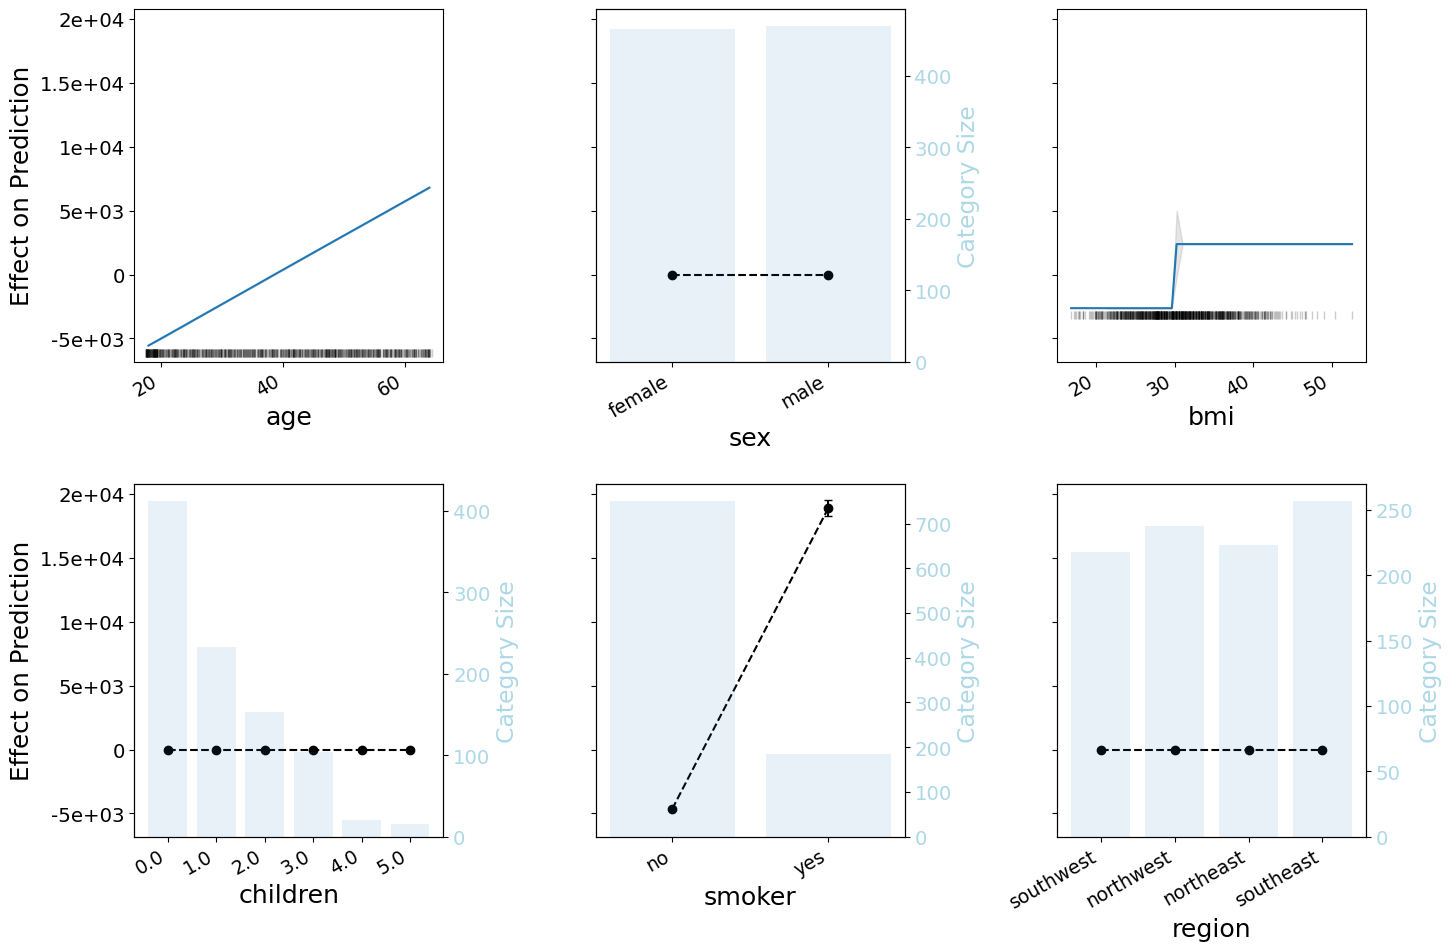

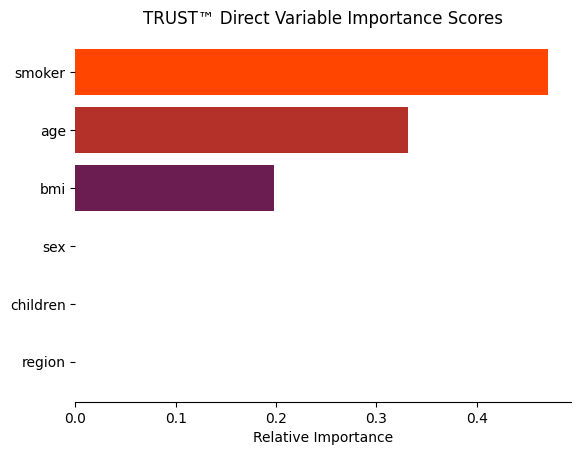

,Importance
smoker,0.47
age,0.33
bmi,0.20
sex,0.00
children,0.00
region,0.00


In [10]:
model.importance("direct", filename="Insurance")

**Insight:** Smoking is by far the most important factor, followed by age and BMI. All other features have zero direct importance. But what about indirect or *systemic* importance? Let's find out.


📊 TRUST™ Systemic Variable Importance ('One Permutation Is All You Need')


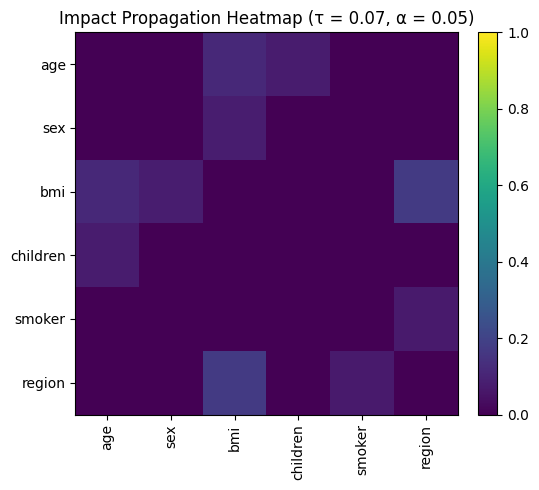

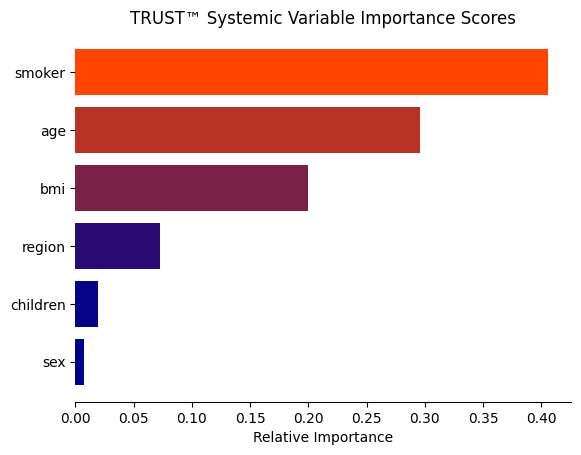

,Importance
smoker,0.41
age,0.30
bmi,0.20
region,0.07
children,0.02
sex,0.01


In [11]:
model.importance("systemic", ALE_plot=False, filename="Insurance")

Look at that! It turns out that region is indirectly used by our model (through proxy variables) even if it does not appear in the split or the leaves of tree. Looking at the impact propagation heatmap, I suspect it's because obesity is not equally prevalent across regions. Let's see if this is true.

In [12]:
X_train.groupby('region')['bmi'].mean()

,bmi
region,
northeast,29.396749
northwest,29.236050
southeast,33.315019
southwest,30.241743


Indeed, in the South East the average BMI is significantly higher than in other regions of the US. But the impact propagation heatmap seems to hint that BMI may not be the only way that region is indirectly used by our model. Perhaps smoking prevalence significantly changes by region as well.

In [13]:
X_train.groupby('region')['smoker'].value_counts(normalize=True)

region     smoker
northeast  no        0.816143
           yes       0.183857
northwest  no        0.827731
           yes       0.172269
southeast  no        0.747082
           yes       0.252918
southwest  no        0.825688
           yes       0.174312
Name: proportion, dtype: float64

Yes, indeed: smoking is much more common in the South East than in other regions of the US. Looks like some policy work could be done in that region — but that's for another day.

## Explaining an Individual Prediction 🔍

Next, let’s zoom in on a **single prediction** to see how **TRUST™** explains its decisions.  
This capability — **unique to trust-free** — is critical in domains like healthcare and finance, where every model decision must be *transparent* and *justifiable*.  

Consider the **3rd test observation**:  

- **27-year-old woman** 👩
- **Smoker** 🚬  
- **Slightly obese** (BMI > 30) ⚖️  

**trust-free** predicts an **astronomical health insurance charge of about \$38,500**.  
At first glance, this seems surprising: *how is it possible that such a young person is predicted to pay that much for health insurance?*

Let’s break down exactly **why trust-free assigns such a high charge**.


🗂 TRUST™ Prediction Report

📈 Predicted charges: 38.5K (very high)
✅ Actual charges: 34.8K (very high)
ℹ️ Discrepancy: 10.46%

ℹ️ Aim: auto (set to 'decrease', as the requested prediction (38.5K) is above the median prediction (10.2K)).
(This parameter only affects text phrasing and the color choice (🟢/🔴) for positive and negative effects; all numerical and graphical analyses remain neutral.)

🔹 Key Factors Behind This Prediction
------------------------------------
Top factors driving this prediction, based on SHAP (SHapley Additive exPlanations) values.
SHAP values show how much each feature increases or decreases this prediction relative to the average prediction.
Positive factors push the prediction upward (🔴); negative ones lower it (🟢).

The most influential factors, ranked by their contribution to your prediction, are listed below:

 - smoker (yes): +24.7K 🔴
 - Medium bmi (31.40): +5.3K 🔴
 - Low age (27): -3.8K 🟢
 - 3 other factors: 0 🟡

Complementing this, the pie chart below 


Summary: This prediction (38.5K) is higher than average (12.2K), mainly due to 2 key factors: smoker ('yes'), and medium bmi.

🔹 Closest Profile
-----------------
This table compares the requested profile to the most similar one with a lower prediction in the same cohort.
It shows how small differences in attributes affect the requested prediction in the direction of interest.

Closest profile comparison table:

                Requested Closest   Effect
age                    27      22  +1.3K 🔴
5 other factors                        0 🟡
Prediction          38.5K   37.2K  +1.3K 🔴

Summary: Your prediction (38.5K) is slightly higher (+4%) than that of its closest profile with a lower one (37.2K). This gap could be reduced if age were lower.

🔹 How Your Prediction Was Made
------------------------------
This section explains the model's logic: your profile followed a path through the decision tree, landing in a group where certain key factors influenced the prediction.
The 'root-to-lea

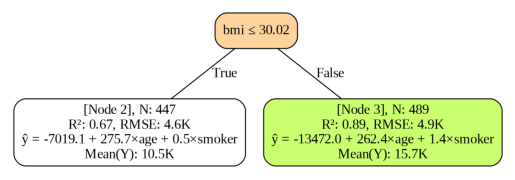

Key factors in this group, ranked by importance:

       Association                                     What this means for you
smoker      Direct  Category 'no' is associated with lower values of charges ✅
age         Direct      Lower age is associated with lower values of charges ✅

Summary: For cases like the one at hand with bmi > 30.02, a lower value of charges is primarily associated with smaller values of age. Category 'no' for smoker correlates most with lower charges.

🔹 Where this Profile Stands
---------------------------
This table compares your profile to others with the lowest and highest predictions.
It shows which factors may drive extreme outcomes. Note: ∆Prediction = Requested - (Low or High).

                      ∆Prediction    Low Requested   High ∆Prediction
smoker                   +27.1K 🔴     no       yes    yes         0 🟡
bmi                       +6.2K 🔴  28.21     31.40  31.30         0 🟡
age                       +2.5K 🔴     18        27     64     -9.7

In [14]:
model.explain(X_test.iloc[2,:], actual=y_test.values[2], filename="Insurance")

We see that although this individual was quite young, the combined effect of being a **smoker** and **clinically obese** turned out to be far more significant than one might expect.  

The *true* insurance charge for this person was $\$34,838.87$, meaning the **trust-free** prediction of $\$38,500$, as large as it seemed, was off by only *10\%* — remarkably accurate given the model's extreme simplicity.

## Comparing 2 profiles head-to-head 🤝

Since version 2.0.0, **trust-free** includes a tool (the `compare()` method) that provides in-depth head-to-head comparisons of pairs of profiles. Let's try it out. For instance, we can compare the previous profile with that of the creator of **trust-free**. I encourage you to play around with this tool and input your own stats if you like!

In [15]:
my_stats = pd.Series([35, 'male', 24, 0, 'no', 'Europe']) # TRUST is unfazed by new levels of categorical features!
model.compare(X_test.iloc[2,:], my_stats)
#model.compare(X_test.iloc[2,:], my_stats, mode = "detailed")


🗂 TRUST™ Profile Comparison Report

🔸 Profile Similarity
--------------------
We measure how close the feature patterns of the requested profiles are based on angular similarity.
Meaning: 0% = opposite profiles, 50% = uncorrelated, 100% = identical.
For categorical variables, similarity reflects how categories influence 'charges' rather than their literal meaning.

 - Similarity: ▰▱▱▱ (Low, 46%)
 - Most similar in: children (0 and 0)
 - Most different in: smoker ('yes' vs. 'no')

🔸 Feature Differences at a Glance
---------------------------------
The radar plot below reveals the main feature differences between the two requested profiles.



Takeaway: The two profiles differ in 5 factors: smoker being 'yes' instead of 'no', sex being 'female' instead of 'male', bmi (31.40 vs. 24), region being 'southwest' instead of 'Europe', and age (27 vs. 35).

🔸 Prediction Difference Analysis
--------------------------------
In this section we compare head-to-head the two requested profiles and relate them to their predictions.
The table below shows how their differences in attributes affect their model predictions.

Profile comparison table:

                Profile 1 Profile 2  Effect
smoker                yes        no  +27.1K
bmi                 31.40        24   +6.2K
age                    27        35   -2.1K
3 other factors                           0
Prediction          38.5K      7.3K  +31.2K

Takeaway: The first profile's prediction (38.5K) is higher (+427%) than that of the second (7.3K). This outcome is influenced by smoker being 'yes' instead of 'no' (⬆) and higher bmi (⬆), which together increase the first prediction by

Takeaway: The two profiles differ in how important each factor is to their respective individual predictions. Specifically, smoker > bmi > age for the first profile, while smoker > age > bmi > Other (3) for the second.

🔸 Conclusion
------------
Low profile similarity translates into a very large prediction difference, in this case.


We observe that the two input profiles are significantly different (e.g., one is a smoker with a high BMI, the other is a non-smoker with a lower BMI), which results in a substantial difference between the predictions generated by the **TRUST™** model. Specifically, the prediction for the second profile (my profile) is notably lower.

Furthermore, the feature contributions for the two predictions diverge:
* While **smoker status** has the most dominant impact in both predictions (+24.7K and -2.4K, respectively),
* The second most important feature in the **first profile** is **BMI** (+5.3K), whereas in the **second profile**, **Age** (-1.7K) holds greater importance.

To perform an even deeper comparison of these two profiles, simply set `mode = "detailed"`.

## TRUST™ vs Other Models 🎯

In this section we will test other popular models and see how they compare to **TRUST™** in terms of accuracy and interpretability.

The alternative models we consider are:
- Decision Tree 🌲
- Random Forest 🌲🌲...🌲
- XGBoost 🌳...🌲...🌴
- Lasso 𓎤

Because there's no honor in winning an unfair fight, we will ***heavily tune the competing models*** to give them the best possible chance to match or exceed **trust-free** in accuracy (even though the latter is used right out of the box).

In [21]:
%%time

# Function to count leaves in XGBoost trees
def count_xgboost_leaves(model):
    # Get tree dumps
    trees = model.get_booster().get_dump()
    total_leaves = 0
    for tree in trees:
        # Count lines that represent leaves (lines with "leaf=")
        leaves_in_tree = len([line for line in tree.split('\n') if 'leaf=' in line])
        total_leaves += leaves_in_tree
    return total_leaves

from sklearn.model_selection import GridSearchCV

models_and_params = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(),
        "params": {
            'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 15],
            'min_samples_split': [2, 3, 4, 5, 10, 20]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=123),
        "params": {
            'n_estimators': [100, 250, 500],
            'max_depth': [2, 4, 6, 8],
            'min_samples_split': [3, 4, 5, 10]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=123),
        "params": {
            'n_estimators': [100, 250],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 4, 6, 8],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    },
    "Lasso": {
        "model": Lasso(),
        "params": {
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
        }
    }
}

# Loop through models for hyperparameter tuning
best_estimators = {}
results = []

for model_name, model_info in models_and_params.items():
    print(f"Tuning {model_name}...")

    # Initialize GridSearchCV
    search = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        scoring='neg_mean_squared_error',
        cv=10,
        n_jobs=-1
    )

    # Fit the model
    search.fit(X_train_1Hot_enc_scaled, y_train)

    # Best estimator and parameters
    best_estimators[model_name] = search.best_estimator_
    best_params = search.best_params_

    if model_name == "Decision Tree":
      num_leaves = search.best_estimator_.get_n_leaves()
      print(f'#leaves in best DT = {num_leaves}')
    elif model_name == "Random Forest":
      num_trees = search.best_estimator_.n_estimators
      num_leaves = sum(tree.get_n_leaves() for tree in search.best_estimator_.estimators_)
      print(f'#trees in best RF = {num_trees}')
      print(f'#leaves in best RF = {num_leaves}')
    elif model_name == "XGBoost":
      num_trees = search.best_estimator_.n_estimators
      num_leaves = count_xgboost_leaves(search.best_estimator_)
      print(f'#trees in best XGB = {num_trees}')
      print(f'#leaves in best XGB = {num_leaves}')
    elif model_name == "Lasso":
      num_nonzero_coefs = np.sum(search.best_estimator_.coef_ != 0)
      print(f'#nonzero coefs in best Lasso = {num_nonzero_coefs}')

    # Evaluate on the test set
    y_pred = search.best_estimator_.predict(X_test_1Hot_enc_scaled)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": model_name,
        "Best Parameters": best_params,
        "RMSE": rmse,
        "R² Score": r2
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

Tuning Decision Tree...
#leaves in best DT = 28
Tuning Random Forest...
#trees in best RF = 250
#leaves in best RF = 4000
Tuning XGBoost...
#trees in best XGB = 100
#leaves in best XGB = 400
Tuning Lasso...
#nonzero coefs in best Lasso = 6
           Model                                    Best Parameters  \
0  Decision Tree          {'max_depth': 5, 'min_samples_split': 20}   
1  Random Forest  {'max_depth': 4, 'min_samples_split': 4, 'n_es...   
2        XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.1...   
3          Lasso                                     {'alpha': 100}   

          RMSE  R² Score  
0  4481.242539  0.859432  
1  4065.846227  0.884285  
2  4059.417880  0.884650  
3  5822.572375  0.762688  
CPU times: user 4.11 s, sys: 370 ms, total: 4.48 s
Wall time: 5min 28s


| Model           | R² (Test)| #Trees | #Leaves or Coefs |
|-----------------|----------|--------|------------------|
| Decision Tree   | 0.86     | 1      | 28               |
| Random Forest   | 0.88     | 250    | 4000             |
| XGBoost         | 0.88     | 100    | 400              |
| Lasso           | 0.76     | "1"    | 1 or 6           |
| **trust-free**  | **0.89** | 1      | 2 or 4 (2+2)     |

> 🚨 **trust-free** not only achieves full interpretability with only two leaves and extremely sparse linear models, but also **slightly exceeds the predictive performance** of even the fully tuned (black-box) ensemble models!

> 🚨 Locally, it remains extremely simple to interpret — even more so than a Lasso model (!) — while delivering **ensemble-level accuracy and beyond**.

## Takeaways 💡

1. **trust-free** achieves (slightly better than) **ensemble-level performance** on a widely used dataset.  
2. Automatically discovers **clinically meaningful splits** (e.g., BMI = 30).  
3. Produces **ultra sparse, interpretable linear models** in each leaf, capturing distinct subgroups.  
4. Intuitive **feature importance**.  
5. Automatically generates detailed **individual prediction explanations** on the fly.

> **Food for thought:** On this dataset, **trust-free** revealed that the seemingly arbitrary BMI threshold of 30 — as defined by the World Health Organization — is actually highly meaningful when predicting health insurance charges, reflecting the severity of health conditions.

## Next Steps ➡️

### Try it yourself! 🚀

- Explain other predictions and compare other observations.
- Explore other datasets to see **trust-free** automatically discover sparse, interpretable models with high predictive performance.


### Contact 📧

We hope this tutorial was useful. Now, with the **trust-free** package under your belt, you'll be ready to tackle with confidence any regression problem thrown your way!

Your feedback helps us improve ❤️ Please share your comments, questions, or suggestions here: [2-minute Feedback Form](https://forms.gle/HDhUXqbrhGVNenE56). To report any technical issues, please open an issue on the project's [GitHub page](https://github.com/adc-trust-ai/trust-free). Don't forget to star ⭐ the project's page if you find it useful!

👉 Want to go further? To be notified when `trust-pro` goes live, make sure to sign-up for our [trust-pro waitlist](https://forms.gle/vQJmip2nXaEEW2K2A).

In [22]:
# Session info

import sys, platform, sklearn, matplotlib, xgboost, plotly, IPython

print("Python:", sys.version)
print("OS:", platform.platform())
print("trust-free:", TRUSTRegressor().__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("xgboost:", xgboost.__version__)
print("plotly:", plotly.__version__)
print("IPython:", IPython.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS: Linux-6.6.113+-x86_64-with-glibc2.35
trust-free: 3.0.0
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.8.0
matplotlib: 3.10.0
xgboost: 3.2.0
plotly: 6.6.0
IPython: 7.34.0
